In [23]:
# Importación de librerías 

import pandas as pd 
from scipy import stats 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import seaborn as sns 
import matplotlib.pyplot as plt 

In [3]:
# Carga de datos 

df = pd.read_csv("../data/raw/clinical_trial_data.csv")
df.head()

,Patient_ID,Age,Gender,BMI,Systolic_BP,Glucose_Level,Treatment_Arm,Dropped_Out
0,PT-0001,60,M,28.9,110.0,64.2,Drug_X,0
1,PT-0002,53,M,24.7,103.0,92.6,Drug_X,0
2,PT-0003,62,F,30.1,133.0,116.5,Placebo,1
3,PT-0004,73,F,28.1,113.0,76.5,Drug_X,1
4,PT-0005,52,M,24.8,117.0,54.9,Drug_X,0


In [4]:
# Total de pacientes en el estudio 

print(f"Total de pacientes = {len(df)}")

Total de pacientes = 1000


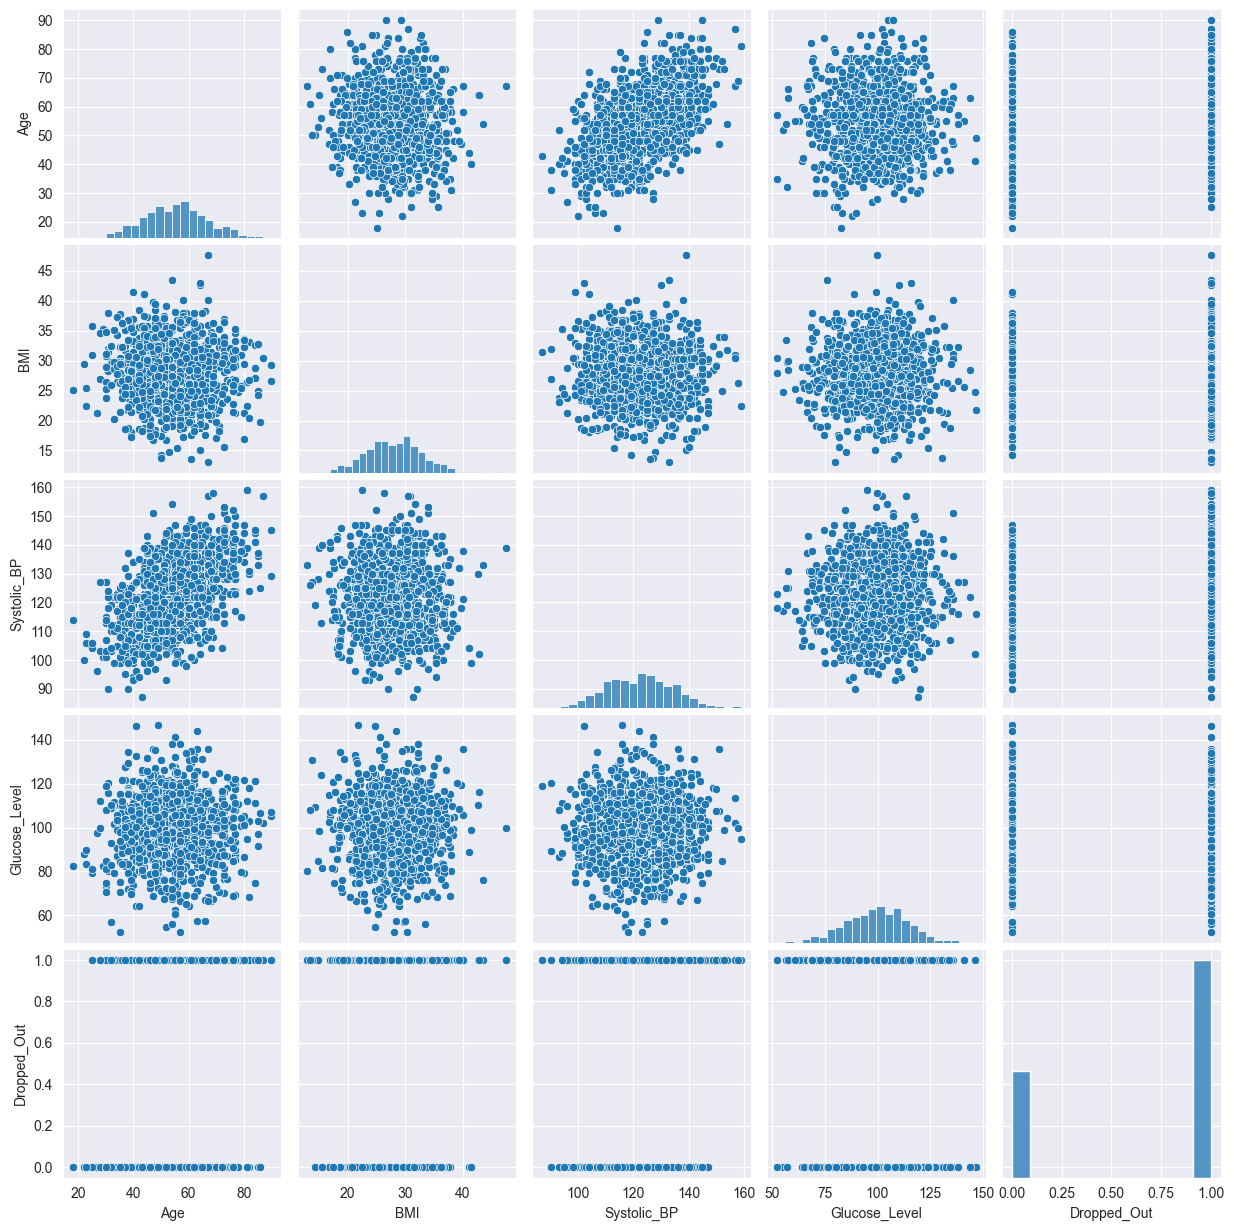

In [26]:
df_numeric = df.drop("Patient_ID", axis = 1)

sns.pairplot(
    data = df_numeric
)

plt.show()

In [34]:
stay_ = df[df['Dropped_Out'] == 1].count() / len(df)
quit_ = df[df['Dropped_Out'] == 0].count() / len(df)

print(f"Proporción de pacientes que se quedaron {stay_}, \nPacientes que abandaron {quit_}")

Proporción de pacientes que se quedaron Patient_ID       0.67
Age              0.67
Gender           0.67
BMI              0.67
Systolic_BP      0.67
Glucose_Level    0.67
Treatment_Arm    0.67
Dropped_Out      0.67
dtype: float64, 
Pacientes que abandaron Patient_ID       0.33
Age              0.33
Gender           0.33
BMI              0.33
Systolic_BP      0.33
Glucose_Level    0.33
Treatment_Arm    0.33
Dropped_Out      0.33
dtype: float64


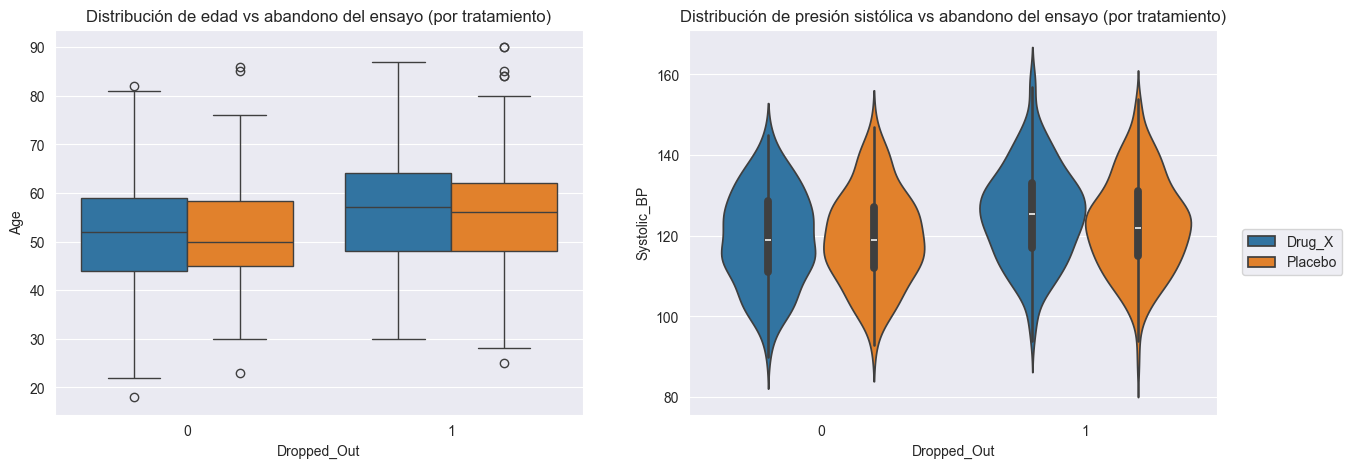

In [36]:
# Análisis de distribución 
sns.set_style("darkgrid")
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(15,5))

sns.boxplot(
    data = df, 
    x = "Dropped_Out", 
    y= 'Age', 
    hue = 'Treatment_Arm', 
    ax = ax1,
    legend = False
)

sns.violinplot(
    data = df, 
    x = "Dropped_Out", 
    y= 'Systolic_BP', 
    hue = 'Treatment_Arm', 
    ax = ax2
)

ax1.set_title("Distribución de edad vs abandono del ensayo (por tratamiento)")
ax2.set_title("Distribución de presión sistólica vs abandono del ensayo (por tratamiento)")
ax2.legend(loc='upper right', bbox_to_anchor=(1.25, 0.5))
plt.show()


In [20]:
# ¿Es la Presión Arterial significativamente diferente en pacientes que abandonan?

bp_stayed = df[df['Dropped_Out'] == 0]['Systolic_BP']
bp_dropped = df[df['Dropped_Out'] == 1]['Systolic_BP']

In [21]:
t_stat, p_value = stats.ttest_ind(bp_stayed, bp_dropped)
print(f"T-Test Presión arterial vs abandono:")
print(f"P-Value: {p_value:.3f}")
if p_value < 0.05:
    print("Conclusión Clínica: Existe una diferencia estadísticamente significativa en la presión arterial de los pacientes que abandonan. ¡Es un biomarcador clave para nuestro modelo ML!\n")
else: 
    print("No hay difrencia estadística significativa")

T-Test Presión arterial vs abandono:
P-Value: 0.000
Conclusión Clínica: Existe una diferencia estadísticamente significativa en la presión arterial de los pacientes que abandonan. ¡Es un biomarcador clave para nuestro modelo ML!



In [22]:
# ¿El tratamiento recibido afecta la tasa de abandono?

contigency_table = pd.crosstab(df['Treatment_Arm'], df['Dropped_Out'])
chi2, p_val_chi, dof, expected = stats.chi2_contingency(contigency_table)
print(f"Chi-Cuadrada Tratamiento vs Abandono:")
print(f"P-Value: {p_val_chi:.3f}")
if p_val_chi < 0.05:
    print("Conclusión Clínica: El tipo de tratamiento (Placebo vs Drug_X) está fuertemente asociado con que el paciente termine el ensayo.")

Chi-Cuadrada Tratamiento vs Abandono:
P-Value: 0.000
Conclusión Clínica: El tipo de tratamiento (Placebo vs Drug_X) está fuertemente asociado con que el paciente termine el ensayo.
